# Modèle voix — Sakar et al. (UCI 470)

Entraînement sur `data/parkinson_disease_classification/pd_speech_features.csv` (756 enregistrements, 252 sujets, 3 enregistrements/sujet).

**Stratégie anti-mismatch** : on sélectionne uniquement les features extraites par Praat (jitter, shimmer, HNR, NHR, RPDE, DFA, PPE) — les mêmes que notre `features.py` utilise via parselmouth à l'inférence. Les features MFCC, wavelet et TQWT sont exclues (non extractibles avec parselmouth).

Features sélectionnées → renommées aux noms UCI 174 pour compatibilité avec le predictor existant.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    f1_score,
    roc_curve,
    classification_report,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Trouver la racine du projet
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "data").exists():
        break
    ROOT = ROOT.parent

DATA_PATH  = ROOT / "data" / "parkinson_disease_classification" / "pd_speech_features.csv"
MODEL_OUT  = ROOT / "models" / "voice_parkinson_xgb.joblib"
MODEL_OUT.parent.mkdir(exist_ok=True)

print("Racine projet :", ROOT)
print("Données       :", DATA_PATH.exists())
print("Modèle sortie :", MODEL_OUT)

Racine projet : c:\Users\conra\Desktop\Perso\Ecole\UQAC\Atelier1\multimodal-parkinson-detection
Données       : True
Modèle sortie : c:\Users\conra\Desktop\Perso\Ecole\UQAC\Atelier1\multimodal-parkinson-detection\models\voice_parkinson_xgb.joblib


## 1. Chargement des données

Le CSV a deux lignes d'en-tête : ligne 0 = catégories, ligne 1 = noms de colonnes. On utilise `header=1`.

In [2]:
df = pd.read_csv(DATA_PATH, header=1)
df['class'] = pd.to_numeric(df['class'], errors='coerce')
df = df[df['class'].notna()].reset_index(drop=True)
df['class'] = df['class'].astype(int)
df['id']    = pd.to_numeric(df['id'],    errors='coerce').astype(int)

print(f"Shape : {df.shape}")
print(f"Sujets uniques : {df['id'].nunique()}")
print(f"\nDistribution classe :")
print(df['class'].value_counts().rename({0: 'Sain (0)', 1: 'Parkinson (1)'}))

Shape : (756, 755)
Sujets uniques : 252

Distribution classe :
class
Parkinson (1)    564
Sain (0)         192
Name: count, dtype: int64


## 2. Sélection des features Praat-compatibles

Correspondance dataset (Praat/OpenSMILE) ↔ noms UCI 174 utilisés dans `features.py` :

| Colonne dataset | Nom UCI 174 (notre features.py) |
|---|---|
| locPctJitter | MDVP:Jitter(%) |
| locAbsJitter | MDVP:Jitter(Abs) |
| rapJitter | MDVP:RAP |
| ppq5Jitter | MDVP:PPQ |
| ddpJitter | Jitter:DDP |
| locShimmer | MDVP:Shimmer |
| locDbShimmer | MDVP:Shimmer(dB) |
| apq3Shimmer | Shimmer:APQ3 |
| apq5Shimmer | Shimmer:APQ5 |
| apq11Shimmer | MDVP:APQ |
| ddaShimmer | Shimmer:DDA |
| meanNoiseToHarmHarmonicity | NHR |
| meanHarmToNoiseHarmonicity | HNR |
| RPDE | RPDE |
| DFA | DFA |
| PPE | PPE |

In [3]:
COLUMN_MAP = {
    "locPctJitter":               "MDVP:Jitter(%)",
    "locAbsJitter":               "MDVP:Jitter(Abs)",
    "rapJitter":                  "MDVP:RAP",
    "ppq5Jitter":                 "MDVP:PPQ",
    "ddpJitter":                  "Jitter:DDP",
    "locShimmer":                 "MDVP:Shimmer",
    "locDbShimmer":               "MDVP:Shimmer(dB)",
    "apq3Shimmer":                "Shimmer:APQ3",
    "apq5Shimmer":                "Shimmer:APQ5",
    "apq11Shimmer":               "MDVP:APQ",
    "ddaShimmer":                 "Shimmer:DDA",
    "meanNoiseToHarmHarmonicity": "NHR",
    "meanHarmToNoiseHarmonicity": "HNR",
    "RPDE":                       "RPDE",
    "DFA":                        "DFA",
    "PPE":                        "PPE",
}

FEATURE_NAMES = list(COLUMN_MAP.values())

feat_df = df[list(COLUMN_MAP.keys())].rename(columns=COLUMN_MAP)
feat_df  = feat_df.apply(pd.to_numeric, errors='coerce')

y      = df['class'].values
groups = df['id'].values

# Imputation NaN par médiane de colonne
feature_medians = feat_df.median()
feat_df = feat_df.fillna(feature_medians)

X = feat_df.values

print(f"Features sélectionnées : {len(FEATURE_NAMES)}")
print(f"X shape : {X.shape}")
print(f"NaN résiduels : {np.isnan(X).sum()}")
print(f"\nMédianes :")
print(feature_medians.round(5).to_string())

Features sélectionnées : 16
X shape : (756, 16)
NaN résiduels : 0

Médianes :
MDVP:Jitter(%)       0.00150
MDVP:Jitter(Abs)     0.00001
MDVP:RAP             0.00028
MDVP:PPQ             0.00065
Jitter:DDP           0.00084
MDVP:Shimmer         0.05573
MDVP:Shimmer(dB)     0.50250
Shimmer:APQ3         0.02798
Shimmer:APQ5         0.03370
MDVP:APQ             0.04754
Shimmer:DDA          0.08394
NHR                  0.01627
HNR                 19.30950
RPDE                 0.48436
DFA                  0.70052
PPE                  0.80966


## 3. EDA rapide

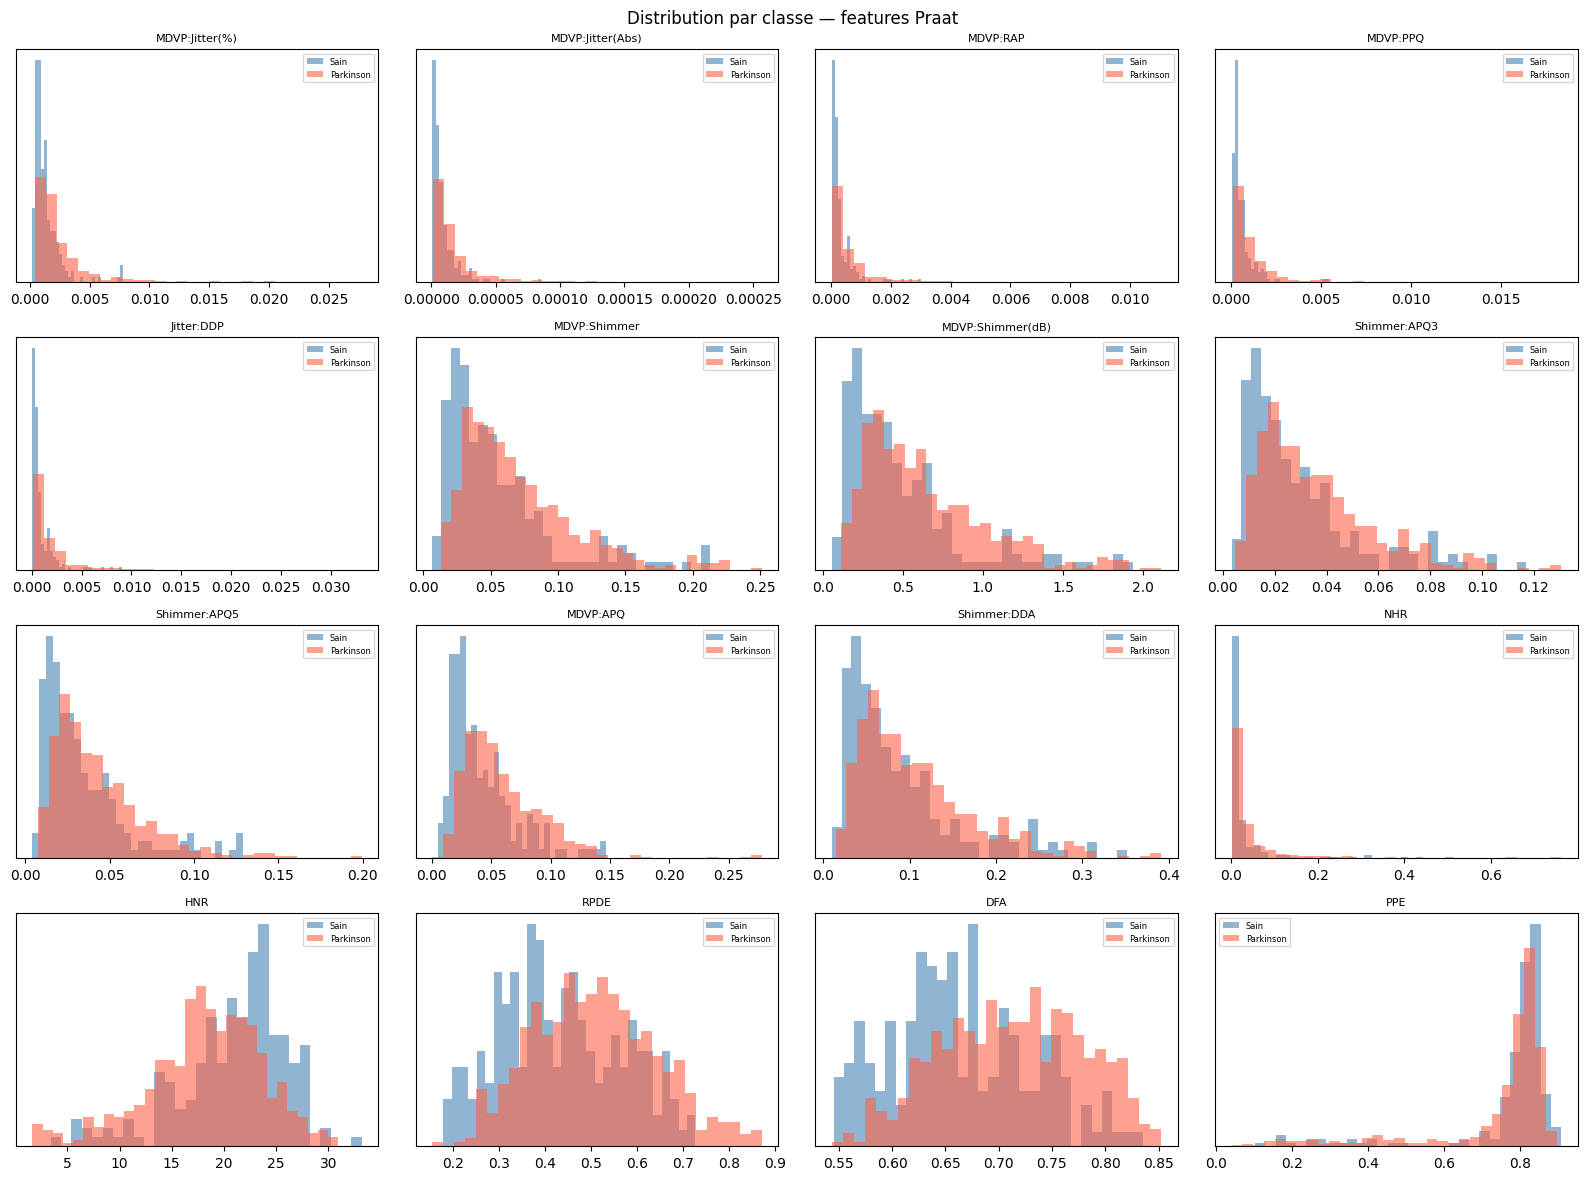

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, name in enumerate(FEATURE_NAMES):
    ax = axes[i]
    for cls, label, color in [(0, 'Sain', 'steelblue'), (1, 'Parkinson', 'tomato')]:
        vals = feat_df.loc[y == cls, name].values
        ax.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(name, fontsize=8)
    ax.legend(fontsize=6)
    ax.set_yticks([])

for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution par classe — features Praat", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Validation croisée groupée (GroupKFold)

On groupe par `id` sujet pour éviter le data leakage inter-enregistrements.

In [5]:
cv = GroupKFold(n_splits=5)

models = {
    "LR": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)),
    ]),
    "XGBoost": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
            eval_metric="logloss", random_state=42, verbosity=0,
        )),
    ]),
}

results = {}
oof_probs = {}

for name, pipe in models.items():
    probs = cross_val_predict(pipe, X, y, groups=groups, cv=cv, method="predict_proba")[:, 1]
    preds = (probs >= 0.5).astype(int)
    results[name] = {
        "ROC-AUC":    roc_auc_score(y, probs),
        "PR-AUC":     average_precision_score(y, probs),
        "F1-macro":   f1_score(y, preds, average="macro"),
        "Bal. Acc.": balanced_accuracy_score(y, preds),
    }
    oof_probs[name] = probs
    print(f"{name} — ROC-AUC: {results[name]['ROC-AUC']:.4f}")

print()
pd.DataFrame(results).T.round(4)

LR — ROC-AUC: 0.7787
SVM-RBF — ROC-AUC: 0.7371
XGBoost — ROC-AUC: 0.7267



,ROC-AUC,PR-AUC,F1-macro,Bal. Acc.
LR,0.7787,0.9061,0.6575,0.6991
SVM-RBF,0.7371,0.8790,0.6044,0.5956
XGBoost,0.7267,0.8753,0.6602,0.6597


## 5. Courbes ROC

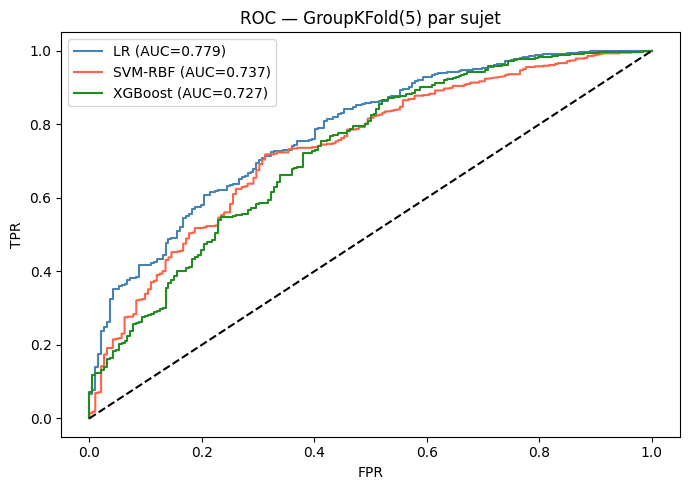

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["steelblue", "tomato", "forestgreen"]
for (name, probs), color in zip(oof_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y, probs)
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — GroupKFold(5) par sujet")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sélection du meilleur modèle et tuning du seuil (Youden's J)

In [7]:
best_name = max(results, key=lambda k: results[k]["ROC-AUC"])
best_probs = oof_probs[best_name]
print(f"Meilleur modèle : {best_name}  (ROC-AUC={results[best_name]['ROC-AUC']:.4f})")

fpr, tpr, thresholds = roc_curve(y, best_probs)
j_scores  = tpr - fpr
best_idx  = np.argmax(j_scores)
best_thr  = float(thresholds[best_idx])

print(f"Seuil optimal (Youden's J) : {best_thr:.4f}")
preds_opt = (best_probs >= best_thr).astype(int)
print(classification_report(y, preds_opt, target_names=["Sain", "Parkinson"]))

Meilleur modèle : LR  (ROC-AUC=0.7787)
Seuil optimal (Youden's J) : 0.5697
              precision    recall  f1-score   support

        Sain       0.41      0.80      0.54       192
   Parkinson       0.90      0.61      0.72       564

    accuracy                           0.65       756
   macro avg       0.65      0.70      0.63       756
weighted avg       0.77      0.65      0.68       756



## 7. Entraînement final sur l'ensemble complet

In [8]:
final_pipe = models[best_name]
final_pipe.fit(X, y)

# Vérification sanité : score sur train (doit être proche de 1)
train_score = roc_auc_score(y, final_pipe.predict_proba(X)[:, 1])
print(f"ROC-AUC train (sanity check) : {train_score:.4f}")

ROC-AUC train (sanity check) : 0.7989


## 8. Export du modèle

In [9]:
artifact = {
    "pipeline":        final_pipe,
    "threshold":       best_thr,
    "feature_names":   FEATURE_NAMES,
    "features":        FEATURE_NAMES,           # alias pour compatibilité predictor
    "feature_medians": feature_medians.to_dict(),
    "dataset":         "Sakar-2019-UCI-470",
    "model":           best_name,
    "n_subjects":      int(df['id'].nunique()),
    "n_samples":       int(len(y)),
    "roc_auc_cv":      float(results[best_name]["ROC-AUC"]),
    "praat_features_only": True,
}

joblib.dump(artifact, MODEL_OUT)
print(f"Modèle exporté → {MODEL_OUT}")
print(f"  Dataset     : {artifact['dataset']}")
print(f"  Modèle      : {artifact['model']}")
print(f"  Sujets      : {artifact['n_subjects']}")
print(f"  ROC-AUC CV  : {artifact['roc_auc_cv']:.4f}")
print(f"  Seuil       : {artifact['threshold']:.4f}")
print(f"  Features ({len(FEATURE_NAMES)}) : {FEATURE_NAMES}")

Modèle exporté → c:\Users\conra\Desktop\Perso\Ecole\UQAC\Atelier1\multimodal-parkinson-detection\models\voice_parkinson_xgb.joblib
  Dataset     : Sakar-2019-UCI-470
  Modèle      : LR
  Sujets      : 252
  ROC-AUC CV  : 0.7787
  Seuil       : 0.5697
  Features (16) : ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


## 9. Test de cohérence : valeurs typiques d'une voix saine

Vérifie que le modèle donne un score < seuil pour des features représentatives d'une voix saine.

In [10]:
# Médiane des sujets sains dans le dataset
healthy_median = feat_df[y == 0].median()
pd_median      = feat_df[y == 1].median()

test_cases = {
    "Sain (médiane contrôles)": healthy_median.values.reshape(1, -1),
    "Parkinson (médiane PD)":   pd_median.values.reshape(1, -1),
}

print(f"Seuil décision : {best_thr:.4f}\n")
for label, X_test in test_cases.items():
    score = float(final_pipe.predict_proba(X_test)[0, 1])
    pred  = "Parkinson" if score >= best_thr else "Sain"
    print(f"{label}: score={score:.3f} → {pred} {'✓' if (label.startswith('Sain') and pred=='Sain') or (label.startswith('Parkinson') and pred=='Parkinson') else '✗'}")

Seuil décision : 0.5697

Sain (médiane contrôles): score=0.325 → Sain ✓
Parkinson (médiane PD): score=0.666 → Parkinson ✓
